# Sea ice differences between resolutions

Do we have differences in sea ice concentration between resolutions?

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client


In [2]:
client = Client(threads_per_worker = 1)

In [3]:
catalog = intake.cat.access_nri

importing SIC and SIT, and EKE and doing monthly means of the last concurrent 3 years

In [4]:
Month_inds = slice(8,10)
time_slice=slice('1997-01','1999-12')
lat_slice=slice(-85,-50)



In [5]:
#importing EKE panan01
dir_file = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
EKE_01 = xr.open_mfdataset(dir_file + 'panan01_rerun/EKE_along_contour/EKE_xyt_panan*.nc').__xarray_dataarray_variable__.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean().sel(month=Month_inds).mean('month').compute()
EKE_01.name= 'EKE'

2025-09-16 11:28:44,571 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 21.48 GiB -- Worker memory limit: 30.62 GiB
2025-09-16 11:28:50,683 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 24.55 GiB -- Worker memory limit: 30.62 GiB
2025-09-16 11:28:54,183 - distributed.worker.memory - WARNING - Worker is at 22% memory usage. Resuming worker. Process memory: 6.79 GiB -- Worker memory limit: 30.62 GiB


In [6]:
%%time 
#importing EKE panan005 : this data is substantially larger so I will need to rechuck to calculate monthly mean
EKE_005 = xr.open_mfdataset(dir_file + 'panan005_rerun/EKE_along_contour/EKE_xyt_panan*.nc',chunks={'xq':76,'yq':1691,'time':1096}).__xarray_dataarray_variable__.sel(time=time_slice).cf.sel(latitude=lat_slice).groupby('time.month').mean().sel(month=Month_inds).mean('month').compute()
EKE_005.name= 'EKE'

CPU times: user 1min 53s, sys: 41.1 s, total: 2min 34s
Wall time: 8min 26s


In [7]:
%%time
#EKE for panan0025.nc  : this data is substantially larger so I will need to rechuck to calculate monthly mean
EKE_0025 = xr.open_mfdataset(dir_file + 'panan0025_rerun/EKE_along_contour/EKE_xyt*panan0025.nc',chunks={'xq':7300,'yq':2262,'time':1094}).__xarray_dataarray_variable__.sel(time=time_slice).cf.sel(latitude=lat_slice).chunk({'xq':int(2*7201//47)}).groupby('time.month').mean().sel(month=Month_inds).mean('month').compute()
EKE_0025.name= 'EKE'

CPU times: user 28.8 s, sys: 9.67 s, total: 38.5 s
Wall time: 1min 20s


In [54]:
#importing SIC
panant01_SIC = catalog["panant-01-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant01_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SIC = panant01_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant01_SIC = panant01_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant005_SIC = catalog["panant-005-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant005_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SIC = panant005_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant005_SIC = panant005_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant0025_SIC = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant0025_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SIC = panant0025_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant0025_SIC = panant0025_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

# #importing SI thickness
panant01_SIT = catalog["panant-01-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant01_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SIT = panant01_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant01_SIT = panant01_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant005_SIT = catalog["panant-005-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant005_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SIT = panant005_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant005_SIT = panant005_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant0025_SIT = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant0025_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SIT = panant0025_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant0025_SIT = panant0025_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

#importing Surface area
panant01_area = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello.cf.sel(latitude=lat_slice)
panant005_area = catalog["panant-005-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello.cf.sel(latitude=lat_slice)
panant0025_area = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello.cf.sel(latitude=lat_slice)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [ ]:
Month_inds = slice(8,10)
SIC01_winter =SIC01.sel(month = Month_inds).mean('month')
SIC005_winter =SIC005.sel(month = Month_inds).mean('month')
SIC0025_winter =SIC0025.sel(month = Month_inds).mean('month')

## Changes in sea ice extent and area

calculating sea ice area

In [9]:
panant01_SIA_mean = (panant01_SIC* panant01_area).sum(('xh','yh')).compute()
panant005_SIA_mean = (panant005_SIC* panant005_area).sum(('xh','yh')).compute()
panant0025_SIA_mean = (panant0025_SIC* panant0025_area).sum(('xh','yh')).compute()

Calculating sea ice extent

In [10]:
SIC_cutoff = 0.15 # cutoff of 15% SIC, lower than that is considered Ice free, higher, ice covered
panant01_SIE_mean = ((0*panant01_SIC.where(panant01_SIC>=SIC_cutoff)+1)* panant01_area).sum(('xh','yh')).compute()
panant005_SIE_mean = ((0*panant005_SIC.where(panant005_SIC>=SIC_cutoff)+1)* panant005_area).sum(('xh','yh')).compute()
panant0025_SIE_mean = ((0*panant0025_SIC.where(panant0025_SIC>=SIC_cutoff)+1)* panant0025_area).sum(('xh','yh')).compute()

In [11]:
#load observational data
OBS_TIME_SLICE = slice("1979", "2022")
sh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4shmday"
nh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nhmday"

In [12]:
def open_cdr_dataset(path, area_file):
    ds = xr.open_dataset(path).rename(
        {'cdr_seaice_conc_monthly': 'cdr_conc', 'xgrid':'x','ygrid':'y'}
    )

    # # we also need the area of each gridcell
    areasNd = np.fromfile(area_file, dtype=np.int32).reshape(
        ds.cdr_conc.isel(time=0).shape
    )
    # # Divide by 1000 to get km2 (https://web.archive.org/web/20170817210544/http://nsidc.org/data/polar-stereo/tools_geo_pixel.html#pixel_area)
    areasKmNd_sh = areasNd / 1000
        
    ds["area"] = xr.DataArray(areasKmNd_sh, dims=["y", "x"])
    ds = ds.set_coords("area")

    ds["cdr_conc"] = ds.cdr_conc.where(ds.cdr_conc<=1)  # convert error codes to Nan

    return ds

In [13]:
!wget --ftp-user=anonymous -nc ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/pss25area_v3.dat ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/psn25area_v3.dat


File ‘pss25area_v3.dat’ already there; not retrieving.
File ‘psn25area_v3.dat’ already there; not retrieving.


In [14]:
from xarray import DataTree, map_over_datasets
from datetime import timedelta

In [15]:
sh_cdr_xr = open_cdr_dataset(sh_obs_url, "pss25area_v3.dat")
cdr_dt = DataTree.from_dict(
    {
        "cdr_sh": sh_cdr_xr,
        # 'cdr_nh':nh_cdr_xr
    }
)

In [16]:
def sea_ice_area(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["X", "Y"])
def sea_ice_area_obs(ds):

    # root dataset in datatree is not used
    if ds is None or 'time' not in ds:
        return ds
    
    sic = ds.cdr_conc
    result = sea_ice_area(sic, sic.area).to_dataset(name="cdr_area")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    return result.sel(time=OBS_TIME_SLICE)

obs_area_dt = cdr_dt.map_over_datasets(sea_ice_area_obs)

In [17]:
def open_by_experiment(exp_name, vars):
    """Concatenate any datasets provided for this experiment into one ds, and add area and geo coordinates"""

    # get the data for each run of this config
    cice_ds = xr.concat(
        [open_by_name(iName, vars) for iName in RUNS[exp_name]], dim="time"
    )

    # We also want the area/lat/lon fields, these are separate datasets, so lets merge them.
    area_ds = xr.merge(
        [open_by_name(RUNS[exp_name][0], iVar) for iVar in VARS_2D]
    ).load()

    # Label the lats and lons
    cice_ds.coords["ni"] = area_ds["xt_ocean"].values
    cice_ds.coords["nj"] = area_ds["yt_ocean"].values

    # Copy attributes for cf compliance
    cice_ds.ni.attrs = area_ds.xt_ocean.attrs
    cice_ds.nj.attrs = area_ds.yt_ocean.attrs

    cice_ds = cice_ds.rename(({"ni": "xt_ocean", "nj": "yt_ocean"}))

    # Add the geolon, geolat, and area as extra co-ordinates fields from area_t

    cice_ds = cice_ds.assign_coords(
        {
            "geolat_t": area_ds.geolat_t,
            "geolon_t": area_ds.geolon_t,
            "area_t": area_ds.area_t,
        }
    )

    # cice timestamps are also misleading:
    cice_ds["time"] = cice_ds.time.to_pandas() - timedelta(minutes=1)

    return cice_ds

def open_by_name(name, vars):
    """Return a dataset for the requested name and vars"""

    return (
        catalog[name]
        .search(variable=vars)
        .to_dask(
            xarray_open_kwargs={
                "chunks": -1 ,
                "decode_coords": False,
            },
            xarray_combine_by_coords_kwargs={
                "compat": "override",
                "data_vars": "minimal",
                "coords": "minimal",
            },
        )
    )

VARS = ["aice_m", "hi_m" ]  # ice area fraction or sea ice concentration, ice thickness averaged by grid cell area
VARS_2D = ["area_t", "geolat_t", "geolon_t"]

In [18]:
def sea_ice_area_model_sh(ds):
    # root dataset in datatree is not used
    if ds is None or 'time' not in ds:
        return ds
    
    sic = ds.aice_m.cf.sel(Y=slice(-90, 0))
    area_km2 = ds.area_t / 1e6

    return sea_ice_area(sic, area_km2).to_dataset(name="si_area").load()
si_name_ds_pairs = dict()
RUNS = {
    "025deg_era5": ["025deg_era5_iaf"],  # (our name: run name(s))
    "025deg_jra55": ["025deg_jra55_iaf_era5comparison"],
    "1deg_era5": ["1deg_era5_iaf"],
    "1deg_jra55": ["1deg_jra55_iaf_era5comparison"],
}
for run in RUNS.keys():
    si_name_ds_pairs[run] = open_by_experiment(run, VARS)
si_dt = DataTree.from_dict(si_name_ds_pairs)
model_area_dt = si_dt.map_over_datasets(sea_ice_area_model_sh)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid

In [19]:
def sea_ice_extent_obs(ds):

    # root dataset in datatree is not used
    if ds is None or 'time' not in ds:
        return ds
    
    sic = ds.cdr_conc
    result = sea_ice_area((0*sic.where(sic>=0.25)+1), sic.area).to_dataset(name="cdr_extent")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    return result.sel(time=OBS_TIME_SLICE)

In [20]:
obs_extent_dt = cdr_dt.map_over_datasets(sea_ice_extent_obs)

In [21]:
CLIMAT_TIME_SLICE = slice("1990-05", "1991-04")
CLIMAT_TIME_SLICE_large =  slice("1991", "2020")

def climatology(ds):
    return ds.sel(time=CLIMAT_TIME_SLICE).groupby("time.month").mean("time")

for group in model_area_dt.groups[1:]:
    climatology(model_area_dt[group].ds.si_area)#.plot(label=group[1:])

NSIDC_climatology  =1e-6 *climatology(obs_area_dt["cdr_sh"].ds.cdr_area)
NSIDC_area = 1e-6 * obs_area_dt["cdr_sh"].ds.cdr_area.sel(time=CLIMAT_TIME_SLICE ).groupby('time.month').mean()
NSIDC_extent = 1e-6 * obs_extent_dt["cdr_sh"].ds.cdr_extent.sel(time=CLIMAT_TIME_SLICE ).groupby('time.month').mean()
NSIDC_area_clim = 1e-6 * obs_area_dt["cdr_sh"].ds.cdr_area.sel(time=CLIMAT_TIME_SLICE_large ).groupby('time.month').mean()
NSIDC_extent_clim  = 1e-6 * obs_extent_dt["cdr_sh"].ds.cdr_extent.sel(time=CLIMAT_TIME_SLICE_large ).groupby('time.month').mean()

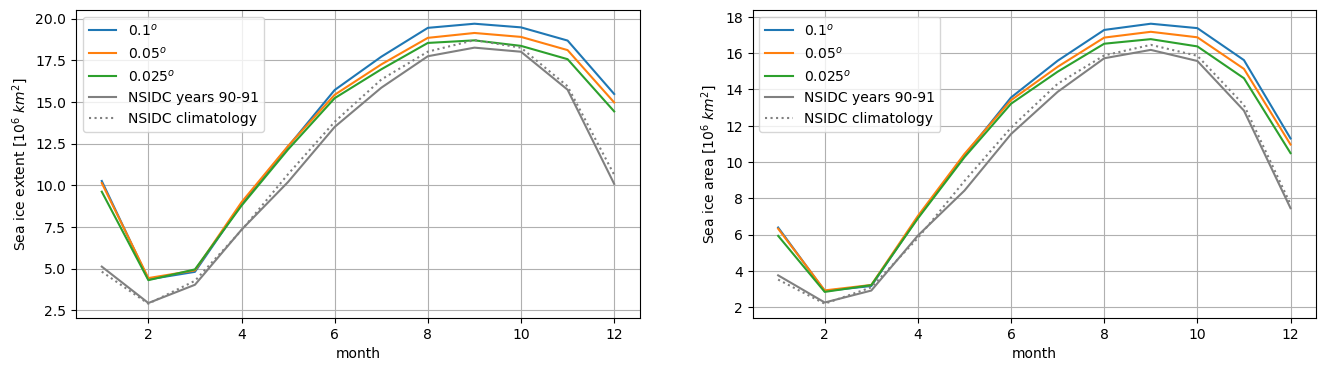

In [22]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
(1e-6 * 1e-6 *panant01_SIE_mean).plot(label=r'$0.1^o$')
(1e-6 * 1e-6 *panant005_SIE_mean).plot(label=r'$0.05^o$')
(1e-6 * 1e-6 *panant0025_SIE_mean).plot(label=r'$0.025^o$')
(NSIDC_extent).plot(label=r'NSIDC years 90-91',color='grey')
(NSIDC_extent_clim).plot(label=r'NSIDC climatology',color='grey',linestyle = ':')
plt.legend()
plt.ylabel(r'Sea ice extent [$10^6 \  km^2$]')
plt.grid()

plt.subplot(1,2,2)
(1e-6 * 1e-6 *panant01_SIA_mean).plot(label=r'$0.1^o$')
(1e-6 * 1e-6 *panant005_SIA_mean).plot(label=r'$0.05^o$')
(1e-6 * 1e-6 *panant0025_SIA_mean).plot(label=r'$0.025^o$')
(NSIDC_area).plot(label=r'NSIDC years 90-91',color='grey')
(NSIDC_area_clim).plot(label=r'NSIDC climatology',color='grey',linestyle = ':')
plt.legend()
plt.ylabel(r'Sea ice area [$10^6 \  km^2$]')
plt.grid()

Maximum sea ice area seem to decrease with resolution, especially between August and October., and it gets closer to obs (tho not perfectly)

## Spatial changes in sea ice thickness and concentration

In [65]:
%%time
Month_inds = slice(8,10)# August septermber and October means

#first SIC        ############################################################################################################
panant01_SIC_mean = panant01_SIC.sel(month=Month_inds).mean('month').compute()
panant005_SIC_mean = panant005_SIC.sel(month=Month_inds).mean('month').compute()
panant0025_SIC_mean = panant0025_SIC.sel(month=Month_inds).mean('month').compute()
# interpolating lower resolutions into the higher one to calcualte differences
panant01_SIC_mean_into0025 = panant01_SIC_mean.interp(xh=panant0025_SIC.xh,yh=panant0025_SIC.yh)
panant005_SIC_mean_into0025 = panant005_SIC_mean.interp(xh=panant0025_SIC.xh,yh=panant0025_SIC.yh)

#second SIT        ############################################################################################################
panant01_SIT_mean = panant01_SIT.sel(month=Month_inds).mean('month').compute()
panant005_SIT_mean = panant005_SIT.sel(month=Month_inds).mean('month').compute()
panant0025_SIT_mean = panant0025_SIT.sel(month=Month_inds).mean('month').compute()
# interpolating lower resolutions into the higher one to calcualte differences
panant01_SIT_mean_into0025 = panant01_SIT_mean.interp(xh=panant0025_SIT.xh,yh=panant0025_SIT.yh)
panant005_SIT_mean_into0025 = panant005_SIT_mean.interp(xh=panant0025_SIT.xh,yh=panant0025_SIT.yh)

CPU times: user 35.1 s, sys: 5.38 s, total: 40.4 s
Wall time: 39.9 s


In [24]:
EKE_01_into0025 = EKE_01.interp(xq=EKE_0025.xq,yq=EKE_0025.yq)
EKE_005_into0025 = EKE_005.interp(xq=EKE_0025.xq,yq=EKE_0025.yq)

Interpolating NSIDC data into panan grid

In [25]:
#importing NSDIC_v4 for extracting extnent map
NSIDC_v4 = xr.open_dataset('/g/data/ik11/observations/seaice/NSIDC_v4/seaice_conc_monthly_sh_197811_202312_v04r00.nc',decode_times=True)
NSIDC_v4['tdim'] = NSIDC_v4.time
NSIDC_v4 = NSIDC_v4.sel(tdim = CLIMAT_TIME_SLICE).groupby('time.month').mean().mean('month')

lat = NSIDC_v4['latitude'].values   # shape (y, x)
lon = NSIDC_v4['longitude'].values  # shape (y, x)
lon = np.where(lon<80,lon,lon-360)
sic = NSIDC_v4['cdr_seaice_conc_monthly']

# Target grid resolution from your array: ~0.01 deg
xh = np.linspace(-280, 80, 14400)
yh = np.linspace(-81.09, -50.0, 2661)

# Create 2D meshgrid of lat/lon
target_lon, target_lat = np.meshgrid(xh, yh)

# Flatten source data
points = np.column_stack((lon.ravel(), lat.ravel()))  # shape (n, 2)
values = sic.values.ravel()  # sea ice concentration

# Mask invalid points
valid_mask = ~np.isnan(values)
points_valid = points[valid_mask]
values_valid = values[valid_mask]

from scipy.interpolate import griddata

# Interpolate
interpolated = griddata(
    points_valid, values_valid,
    (target_lon, target_lat),
    method='nearest'  # or 'linear', but 'nearest' better handles edges
)

sic_regridded = xr.DataArray(
    interpolated.astype(np.float32),
    coords={'yh': yh, 'xh': xh},
    dims=('yh', 'xh'),
    name='sic_regridded'
)
sic_regridded = sic_regridded.where(sic_regridded<=1)

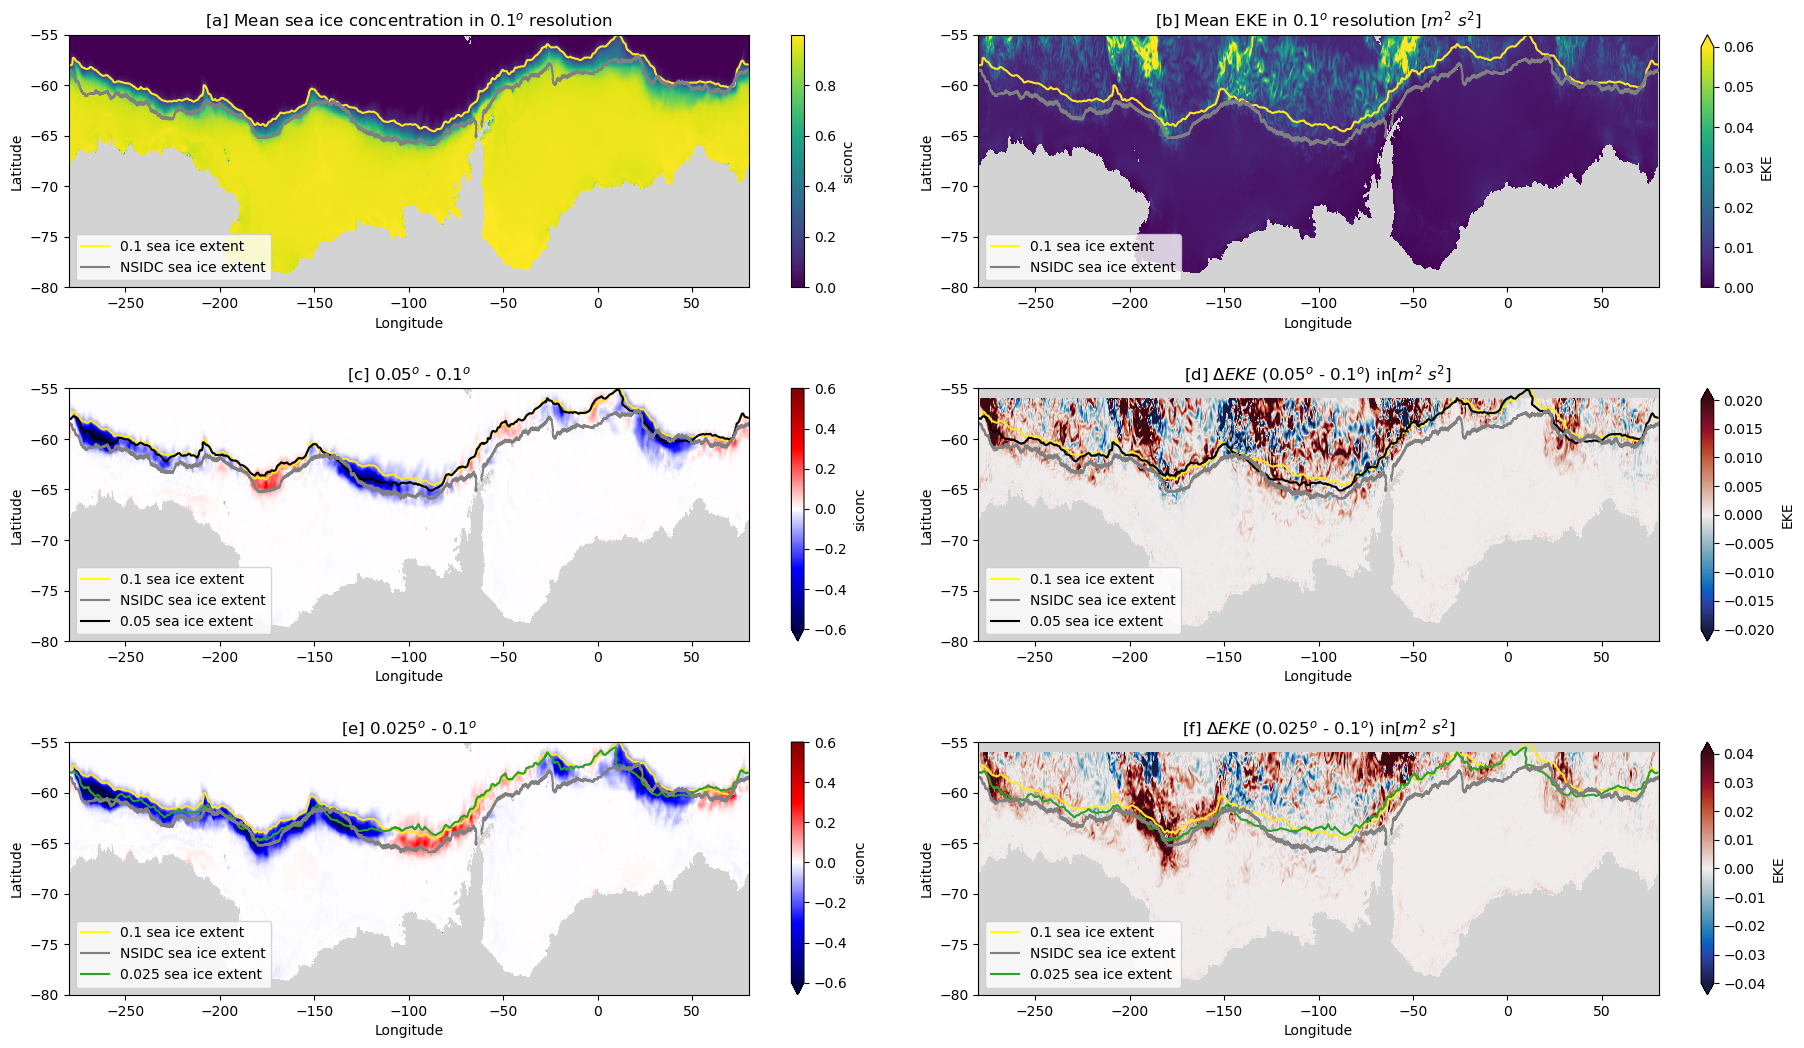

In [26]:
plt.figure(figsize=(22,12))

plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.07, hspace=0.4)

ax321 = plt.subplot(3,2,1)
panant01_SIC_mean.plot()
panant01_SIC_mean.plot.contour(levels=[0.15,])
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[a] Mean sea ice concentration in $0.1^o$ resolution')
plt.ylim(-80,-55)
ax321.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.legend(loc='lower left')

ax322 = plt.subplot(3,2,2)
EKE_01.plot(vmin=0,vmax=0.06)
panant01_SIC_mean.plot.contour(levels=[0.15,])
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[b] Mean EKE in $0.1^o$ resolution [$m^2 \ s^2$]')
plt.ylim(-80,-55)
ax322.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.legend(loc='lower left')


ax323 = plt.subplot(3,2,3)
panant01_SIC_mean.plot.contour(levels=[0.15,])
panant005_SIC_mean.plot.contour(levels=[0.15,],colors='black')
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
(panant005_SIC_mean_into0025 - panant01_SIC_mean_into0025).plot(vmin=-.6,vmax=.6,cmap='seismic')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[c] $0.05^o$ - $0.1^o$')
plt.ylim(-80,-55)
ax323.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.plot(-90,-90,color='black',label='0.05 sea ice extent')
plt.legend(loc='lower left')


ax324 = plt.subplot(3,2,4)
(EKE_005_into0025 - EKE_01_into0025).plot(vmin=-0.02,vmax=0.02,cmap=cmocean.balance)
panant01_SIC_mean.plot.contour(levels=[0.15,])
panant005_SIC_mean.plot.contour(levels=[0.15,],colors='black')
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[d] $\Delta EKE$ ($0.05^o$ - $0.1^o$) in[$m^2 \ s^2$]')
plt.ylim(-80,-55)
ax324.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.plot(-90,-90,color='black',label='0.05 sea ice extent')
plt.legend(loc='lower left')

ax325 = plt.subplot(3,2,5)
panant01_SIC_mean.plot.contour(levels=[0.15,])
panant0025_SIC_mean.plot.contour(levels=[0.15,],colors='tab:green')
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
(panant0025_SIC_mean - panant01_SIC_mean_into0025).plot(vmin=-.6,vmax=.6,cmap='seismic')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[e] $0.025^o$ - $0.1^o$')
plt.ylim(-80,-55)
ax325.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.plot(-90,-90,color='tab:green',label='0.025 sea ice extent')
plt.legend(loc='lower left')


ax326 = plt.subplot(3,2,6)
(EKE_0025 - EKE_01_into0025).plot(vmin=-0.04,vmax=0.04,cmap=cmocean.balance)
panant01_SIC_mean.plot.contour(levels=[0.15,])
panant0025_SIC_mean.plot.contour(levels=[0.15,],colors='tab:green')
sic_regridded.plot.contour(levels=[0.15,],colors='grey')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[f] $\Delta EKE$ ($0.025^o$ - $0.1^o$) in[$m^2 \ s^2$]')
plt.ylim(-80,-55)
ax326.set_facecolor('lightgray')
plt.plot(-90,-90,color='yellow',label='0.1 sea ice extent')
plt.plot(-90,-90,color='grey',label='NSIDC sea ice extent')
plt.plot(-90,-90,color='tab:green',label='0.025 sea ice extent')
plt.legend(loc='lower left')

#plt.savefig('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/SIC_SIE_EKE.png',dpi=300,bbox_inches='tight')

ok, that is interesting!, tho the signal is not super clear

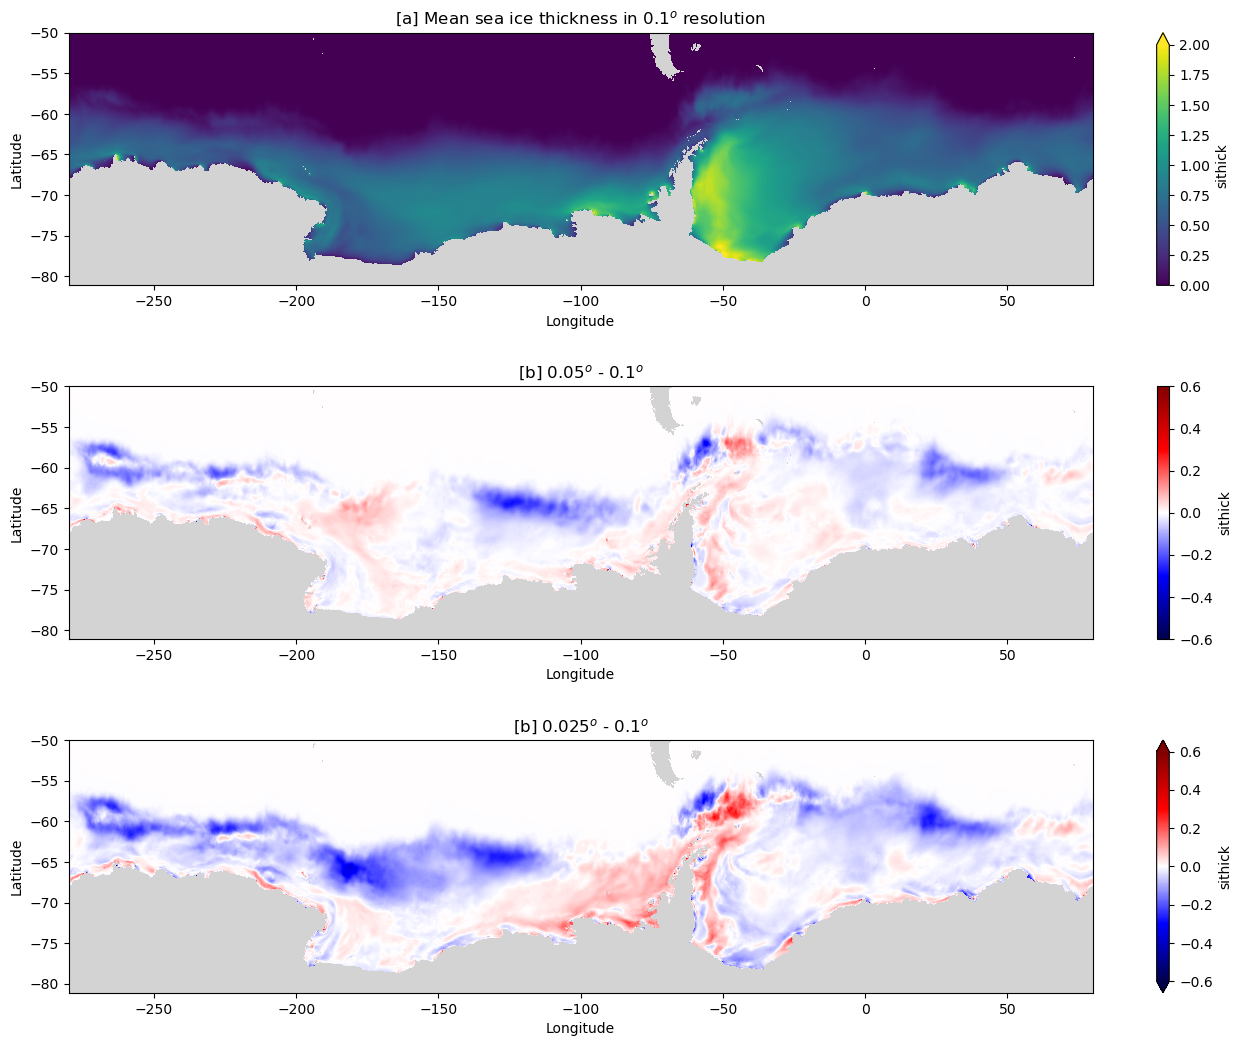

In [27]:
plt.figure(figsize=(16,12))

plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.07, hspace=0.4)

ax311 = plt.subplot(3,1,1)
panant01_SIT_mean.plot(vmin=0,vmax=2)
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title(r'[a] Mean sea ice thickness in $0.1^o$ resolution')
ax311.set_facecolor('lightgray')

ax312 = plt.subplot(3,1,2)
(panant005_SIT_mean_into0025 - panant01_SIT_mean_into0025).plot(vmin=-.6,vmax=.6,cmap='seismic')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title('[b] $0.05^o$ - $0.1^o$')
ax312.set_facecolor('lightgray')

ax313 = plt.subplot(3,1,3)
(panant0025_SIT_mean - panant01_SIT_mean_into0025).plot(vmin=-.6,vmax=.6,cmap='seismic')
plt.ylabel('Latitude'); plt.xlabel('Longitude')
plt.title('[b] $0.025^o$ - $0.1^o$')
ax313.set_facecolor('lightgray')

can we bin SIC and SST changes into EKE changes?

In [28]:
from xhistogram.xarray import histogram

In [57]:
#importing temperature
panant01_SST = catalog["panant-01-zstar-ACCESSyr2"].search(variable="thetao", frequency = '1mon')
panant01_SST.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SST = panant01_SST.to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.isel(z_l=0).cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()


panant005_SST = catalog["panant-005-zstar-ACCESSyr2"].search(variable="thetao", frequency = '1mon',file_id='ocean.1mon.nv:2.xh:7200.xq:7201.yh:1690.yq:1691.z_i:76.z_l:75')
panant005_SST.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SST = panant005_SST.to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.isel(z_l=0).cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()


panant0025_SST = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="thetao", frequency = '1mon',file_id = 'ocean.1mon.nv:2.xh:14400.xq:14401.yh:3383.yq:3384.z_i:76.z_l:75')
panant0025_SST.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SST = panant0025_SST.to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.isel(z_l=0).cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [58]:
#bins to use
SIC_bins = np.linspace(-1,0,1500)
Edge_lat_slice=slice(-67,-55)
cutoff_delta = 5e-3

# first for panan005
deltaSIC_005 = (panant005_SIC_mean_into0025 - panant01_SIC_mean_into0025)
deltaSIC_005 = deltaSIC_005.sel(yh=Edge_lat_slice) #separeating SI edge
cutoff_mask = ((deltaSIC_005**2)**0.5); cutoff_mask=0*cutoff_mask.where(cutoff_mask>=cutoff_delta)+1
delta_EKE005 = (EKE_005_into0025 - EKE_01_into0025).interp(xq=panant01_SIC_mean_into0025.xh,yq=panant01_SIC_mean_into0025.yh).sel(yh=Edge_lat_slice)
delta_EKE005.name= 'deltaEKE'
panant0025_area_slice = panant0025_area.sel(yh=Edge_lat_slice)

# now for panan0025
deltaSIC_0025 = (panant0025_SIC_mean - panant01_SIC_mean_into0025)
deltaSIC_0025 = deltaSIC_0025.sel(yh=Edge_lat_slice) #separeating SI edge
cutoff_mask = ((deltaSIC_0025**2)**0.5); cutoff_mask=0*cutoff_mask.where(cutoff_mask>=cutoff_delta)+1
delta_EKE0025 = (EKE_0025 - EKE_01_into0025).interp(xq=panant01_SIC_mean_into0025.xh,yq=panant01_SIC_mean_into0025.yh).sel(yh=Edge_lat_slice)
delta_EKE0025.name= 'deltaEKE'


In [59]:
EKE005intoSIC = (histogram(deltaSIC_005, 
                          bins = SIC_bins, 
                          dim = ['xh','yh'],
                          weights = delta_EKE005*panant0025_area_slice) /\
    histogram(deltaSIC_005, 
                          bins = SIC_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

EKE0025intoSIC = (histogram(deltaSIC_0025, 
                          bins = SIC_bins, 
                          dim = ['xh','yh'],
                          weights = delta_EKE0025*panant0025_area_slice) /\
    histogram(deltaSIC_0025, 
                          bins = SIC_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.da

In [60]:
#loading SST
panant01_SST.load()
panant005_SST.load()
panant0025_SST.load()
print('SST loaded')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 58.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 68.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SST loaded


In [66]:
#Interpolating SST into a common resolution
panant01_SST_mean_into0025 = panant01_SST.sel(month=Month_inds).mean('month').interp(xh = panant0025_SST.xh, yh = panant0025_SST.yh)
panant005_SST_mean_into0025 = panant005_SST.sel(month=Month_inds).mean('month').interp(xh = panant0025_SST.xh, yh = panant0025_SST.yh)
panant0025_SST_mean_into0025 = panant0025_SST.sel(month=Month_inds).mean('month')


In [76]:
#calculating deltas for SST
# # first for panan005
deltaSST_005 = (panant005_SST_mean_into0025 - panant01_SST_mean_into0025)
deltaSST_005 = deltaSST_005.sel(yh=Edge_lat_slice) #separeating SI edge
cutoff_mask = ((deltaSIC_005**2)**0.5); cutoff_mask=0*cutoff_mask.where(cutoff_mask>=cutoff_delta)+1


# # first for panan0025
deltaSST_0025 = (panant0025_SST_mean_into0025 - panant01_SST_mean_into0025)
deltaSST_0025 = deltaSST_0025.sel(yh=Edge_lat_slice) #separeating SI edge
cutoff_mask = ((deltaSIC_005**2)**0.5); cutoff_mask=0*cutoff_mask.where(cutoff_mask>=cutoff_delta)+1

Binning SST changes into EKE changes

In [94]:
SST_bins  = np.linspace(1.5,2.6,1500)

EKE005intoSST = (histogram(deltaSST_005, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = delta_EKE005*panant0025_area_slice) /\
    histogram(deltaSST_005, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

EKE0025intoSST = (histogram(deltaSST_0025, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = delta_EKE0025*panant0025_area_slice) /\
    histogram(deltaSST_0025, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.da

Binning SST changes into SIC chages

In [102]:
SIC005intoSST = (histogram(deltaSST_005, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = deltaSIC_005*panant0025_area_slice) /\
    histogram(deltaSST_005, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

SIC0025intoSST = (histogram(deltaSST_0025, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = deltaSIC_0025*panant0025_area_slice) /\
    histogram(deltaSST_0025, 
                          bins = SST_bins, 
                          dim = ['xh','yh'],
                          weights = panant0025_area_slice) ).compute().rename()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 219.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.da

Text(0.5, 1.0, '[b] EKE anomalies, binned into SST anomalies\n between $67^o S$ and $55^o S$')

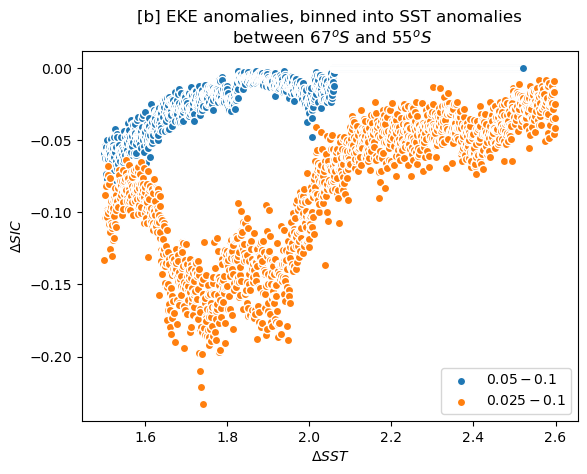

In [105]:
SIC005intoSST.plot.scatter(label=r'$0.05 - 0.1$')
SIC0025intoSST.plot.scatter(label=r'$0.025 - 0.1$')
#plt.xlim(1.5,2.8)
plt.xlabel(r'$\Delta SST$')
plt.ylabel(r'$\Delta SIC$')
plt.legend()
plt.title(r'[b] EKE anomalies, binned into SST anomalies' + '\n between $67^o S$ and $55^o S$')

Text(0.5, 1.0, '[b] EKE anomalies, binned into SST anomalies\n between $67^o S$ and $55^o S$')

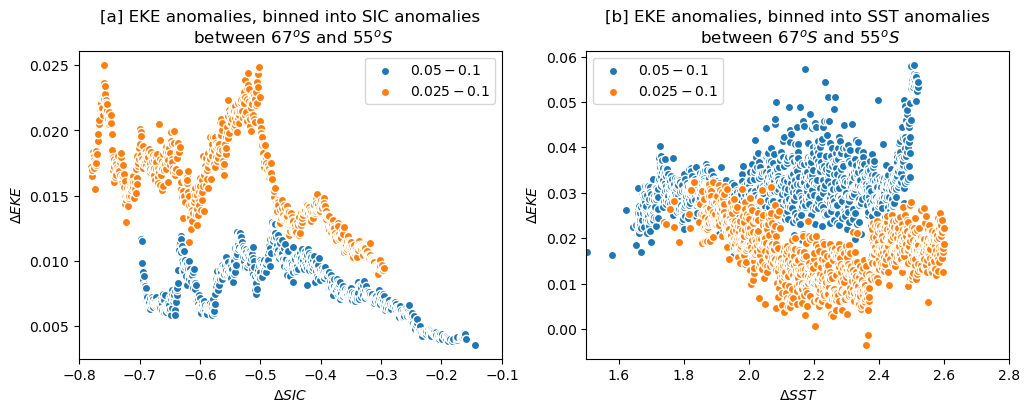

In [97]:
plt.figure(figsize = (12, 4))

plt.subplot(1,2,1)
EKE005intoSIC.plot.scatter(label=r'$0.05 - 0.1$')
EKE0025intoSIC.plot.scatter(label=r'$0.025 - 0.1$')
plt.xlim(-.8,-.1)
plt.xlabel(r'$\Delta SIC$')
plt.ylabel(r'$\Delta EKE$')
plt.legend()
plt.title(r'[a] EKE anomalies, binned into SIC anomalies' + '\n between $67^o S$ and $55^o S$')

plt.subplot(1,2,2)
EKE005intoSST.plot.scatter(label=r'$0.05 - 0.1$')
EKE0025intoSST.plot.scatter(label=r'$0.025 - 0.1$')
plt.xlim(1.5,2.8)
plt.xlabel(r'$\Delta SST$')
plt.ylabel(r'$\Delta EKE$')
plt.legend()
plt.title(r'[b] EKE anomalies, binned into SST anomalies' + '\n between $67^o S$ and $55^o S$')

We do seem to have a bit of a relationship between EKE and SIC changes here. Which one rules which is a thing to think about. Perhaps we can do a few things like...
-  Similar plot with SST
- Look at heat fluxes co-located to EKE. Do we have especially posite anomalies in heat fluxes in the sites with positive anomalies in EKE? This would strengthen the idea of eddies driving melting. not a proof tho
- Also, do we have basal melting rates in sea ice? we could regress those too if so